# Trainee CIS 2026 - Stellar Classification
## Diogo Oliveira Ferreira

- Nesse Notebook tem a parte 1 da solução da Fase 2 do IEEE, onde treinamos um modelo de Redes Neurais para classificar estrelas entre Galaxy, QSO e STAR.

- Utilizei técnicas de Pré-Processamento para melhorar o treinamento do modelo.
- Testei múltiplas possibilidades de arquitetura das Redes Neurais + Hiperparametros variados
- Ao final, tem todos os gráficos de Loss e Acurácia dos modelos diferentes junto com suas matrizes de confusão.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import warnings; warnings.filterwarnings('ignore')
from google.colab import drive

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device: ', device)

id_do_arquivo = '1QMxakq1CqJwOIZ1MIPRjoYGkXZBcrLMC'
url_download_direto = f'https://docs.google.com/uc?export=download&id={id_do_arquivo}'

df = pd.read_csv(url_download_direto)
df.head()

device:  cuda


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


# 1. Pré-Processamento

- Remoção das colunas que julguei serem desnecessárias, a maior parte das que foram excluídas são as de IDs.
- Transformei as classes de "Galaxy", "QSO" e "STAR" para números, diminuindo o tamanho do arquivo e facilitando o treinamento do modelo.

In [2]:
df = pd.read_csv('star_classification.csv')

drop_cols = ['obj_ID','run_ID','rerun_ID','cam_col','field_ID',
             'spec_obj_ID','plate','MJD','fiber_ID']
df = df.drop(columns=drop_cols)

le = LabelEncoder()

# Transformação da coluna de 'class'
y  = le.fit_transform(df['class'])  # GALAXY/QSO/STAR --> 0/1/2

X  = df.drop(columns=['class']).values.astype(np.float32)

Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

sc = StandardScaler().fit(Xtr)
Xtr = sc.transform(Xtr).astype(np.float32)
Xte = sc.transform(Xte).astype(np.float32)

def to_loader(X, y, bs=256, shuffle=True):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y).long())
    return DataLoader(ds, batch_size=bs, shuffle=shuffle)

tr_loader = to_loader(Xtr, ytr)
te_loader = to_loader(Xte, yte, shuffle=False)

print(f'train {Xtr.shape} | test {Xte.shape}')
print(f'classes: {dict(zip(le.classes_, range(len(le.classes_))))}')

train (80000, 8) | test (20000, 8)
classes: {'GALAXY': 0, 'QSO': 1, 'STAR': 2}


# 2. Setup dos Multi Layer Perceptrons

- Nessa seção, realizamos a montagem das camadas da Rede Neural manualmente, declaramos uma classe de MLP, utilizando as funcionalidades da biblioteca do PyTorch.

In [3]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden=(64,32), n_classes=3, p_drop=0.0):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            if p_drop > 0:
                layers.append(nn.Dropout(p_drop))
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

@torch.no_grad()
def evaluate(model, loader, crit):
    model.eval()
    loss_sum = correct = n = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        loss_sum += crit(out, yb).item() * len(yb)
        correct  += (out.argmax(1) == yb).sum().item()
        n += len(yb)
    return loss_sum / n, correct / n

@torch.no_grad()
def predict(model, loader):
    model.eval()
    ys, ps = [], []
    for xb, yb in loader:
        ps.append(model(xb.to(device)).argmax(1).cpu().numpy())
        ys.append(yb.numpy())
    return np.concatenate(ys), np.concatenate(ps)

def fit(model, tr, te, epochs=30, lr=1e-3, wd=0.0):
    opt  = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    crit = nn.CrossEntropyLoss()
    hist = {'tr_loss':[], 'te_loss':[], 'tr_acc':[], 'te_acc':[]}

    for ep in range(1, epochs+1):
        model.train()
        for xb, yb in tr:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss = crit(model(xb), yb)
            loss.backward(); opt.step()
        trl, tra = evaluate(model, tr, crit)
        tel, tea = evaluate(model, te, crit)
        hist['tr_loss'].append(trl); hist['te_loss'].append(tel)
        hist['tr_acc'].append(tra);  hist['te_acc'].append(tea)
    return hist

# 3. Experimentação de Parametros

- Aqui testei alguns tipos diferentes de arquitetura, algumas mais fundas de até 3 camadas e outras mais rasas, variando a largura, épocas e learning rate delas.

In [4]:
configs = {
    '1':  dict(hidden=[32],        lr=1e-3, epochs=30,  p_drop=0.0, wd=0.0),    # 1 camada com poucos neuronios
    '2':  dict(hidden=[128],       lr=1e-3, epochs=30,  p_drop=0.0, wd=0.0),    # 1 camada com muitos neuronios
    '3':  dict(hidden=[64,32],     lr=1e-3, epochs=30,  p_drop=0.0, wd=0.0),    # 2 camadas com 64 e 32 neuronios --> Baseline
    '4':  dict(hidden=[128,64,32], lr=1e-3, epochs=30,  p_drop=0.0, wd=0.0),    # 3 camadas
    '5':  dict(hidden=[64,32],     lr=1e-2, epochs=30,  p_drop=0.0, wd=0.0),    # lr alta --> 0.01
    '6':  dict(hidden=[64,32],     lr=1e-4, epochs=30,  p_drop=0.0, wd=0.0),    # lr baixa --> 0.0001
    '7':  dict(hidden=[128,64,32], lr=1e-3, epochs=100, p_drop=0.0, wd=0.0),    # 100 epochs --> Possivel Overfit
    '8':  dict(hidden=[128,64,32], lr=1e-3, epochs=100, p_drop=0.3, wd=0),      # 100 epochs + 30% de dropout
    '9':  dict(hidden=[128,64,32], lr=1e-3, epochs=100, p_drop=0.3, wd=1e-4),   # 100 epochs + 30% de dropout + L2
}

# 4. Treinamento

In [5]:
results = {}

for name, cfg in configs.items():
    print(f'\n{"="*60}')
    print(f'CONFIG: {name}')
    print(f'  hidden={cfg["hidden"]} lr={cfg["lr"]} epochs={cfg["epochs"]} '
          f'dropout={cfg["p_drop"]} wd={cfg["wd"]}')
    print(f'{"-"*60}')

    torch.manual_seed(SEED)
    model = MLP(Xtr.shape[1], hidden=cfg['hidden'],
                p_drop=cfg['p_drop']).to(device)

    n_params = sum(p.numel() for p in model.parameters())
    print(f'  params: {n_params}')

    hist = fit(model, tr_loader, te_loader,
               epochs=cfg['epochs'], lr=cfg['lr'], wd=cfg['wd'])

    y_true, y_pred = predict(model, te_loader)

    results[name] = {
        'hist': hist,
        'y_true': y_true,
        'y_pred': y_pred,
        'cfg': cfg,
        'n_params': n_params,
        'final_tr_acc': hist['tr_acc'][-1],
        'final_te_acc': hist['te_acc'][-1],
        'final_tr_loss': hist['tr_loss'][-1],
        'final_te_loss': hist['te_loss'][-1],
    }

    print(f'  Accuracy: tr_acc={hist["tr_acc"][-1]:.4f}  te_acc={hist["te_acc"][-1]:.4f}')

print('\n✅ Todas as configs treinadas.')


CONFIG: 1
  hidden=[32] lr=0.001 epochs=30 dropout=0.0 wd=0.0
------------------------------------------------------------
  params: 387
  Accuracy: tr_acc=0.9657  te_acc=0.9669

CONFIG: 2
  hidden=[128] lr=0.001 epochs=30 dropout=0.0 wd=0.0
------------------------------------------------------------
  params: 1539
  Accuracy: tr_acc=0.9677  te_acc=0.9690

CONFIG: 3
  hidden=[64, 32] lr=0.001 epochs=30 dropout=0.0 wd=0.0
------------------------------------------------------------
  params: 2755
  Accuracy: tr_acc=0.9707  te_acc=0.9719

CONFIG: 4
  hidden=[128, 64, 32] lr=0.001 epochs=30 dropout=0.0 wd=0.0
------------------------------------------------------------
  params: 11587
  Accuracy: tr_acc=0.9702  te_acc=0.9708

CONFIG: 5
  hidden=[64, 32] lr=0.01 epochs=30 dropout=0.0 wd=0.0
------------------------------------------------------------
  params: 2755
  Accuracy: tr_acc=0.9660  te_acc=0.9673

CONFIG: 6
  hidden=[64, 32] lr=0.0001 epochs=30 dropout=0.0 wd=0.0
---------------

# 5. Tabela Resumo

- Aqui temos todos as métricas normais do treinamento, sem F1-Score ou métricas calculadas no momento.

In [6]:
rows = []
for name, r in results.items():
    rows.append({
        'Config': name,
        'Params': r['n_params'],
        'Train Acc': f'{r["final_tr_acc"]:.4f}',
        'Test Acc':  f'{r["final_te_acc"]:.4f}',
        'Train Loss': f'{r["final_tr_loss"]:.4f}',
        'Test Loss':  f'{r["final_te_loss"]:.4f}',
        'Gap (tr-te)': f'{r["final_tr_acc"]-r["final_te_acc"]:.4f}',
    })
summary = pd.DataFrame(rows)
summary

,Config,Params,Train Acc,Test Acc,Train Loss,Test Loss,Gap (tr-te)
0,1,387,0.9657,0.9669,0.1185,0.1192,-0.0012
1,2,1539,0.9677,0.9690,0.1089,0.1097,-0.0013
2,3,2755,0.9707,0.9719,0.0972,0.0995,-0.0012
3,4,11587,0.9702,0.9708,0.0980,0.1015,-0.0006
4,5,2755,0.9660,0.9673,0.1073,0.1064,-0.0012
5,6,2755,0.9598,0.9606,0.1377,0.1371,-0.0008
6,7,11587,0.9753,0.9742,0.0818,0.0898,0.0010
7,8,11587,0.9731,0.9730,0.0871,0.0914,0.0001
8,9,11587,0.9713,0.9720,0.0951,0.0965,-0.0007


# 6. Gráficos de Loss/Acc

- Nessa seção, temos os gráficos respectivos de cada um dos experimentos, mostrando como cada arquitetura e variação de hiperparametros impacta o resultado do modelo.

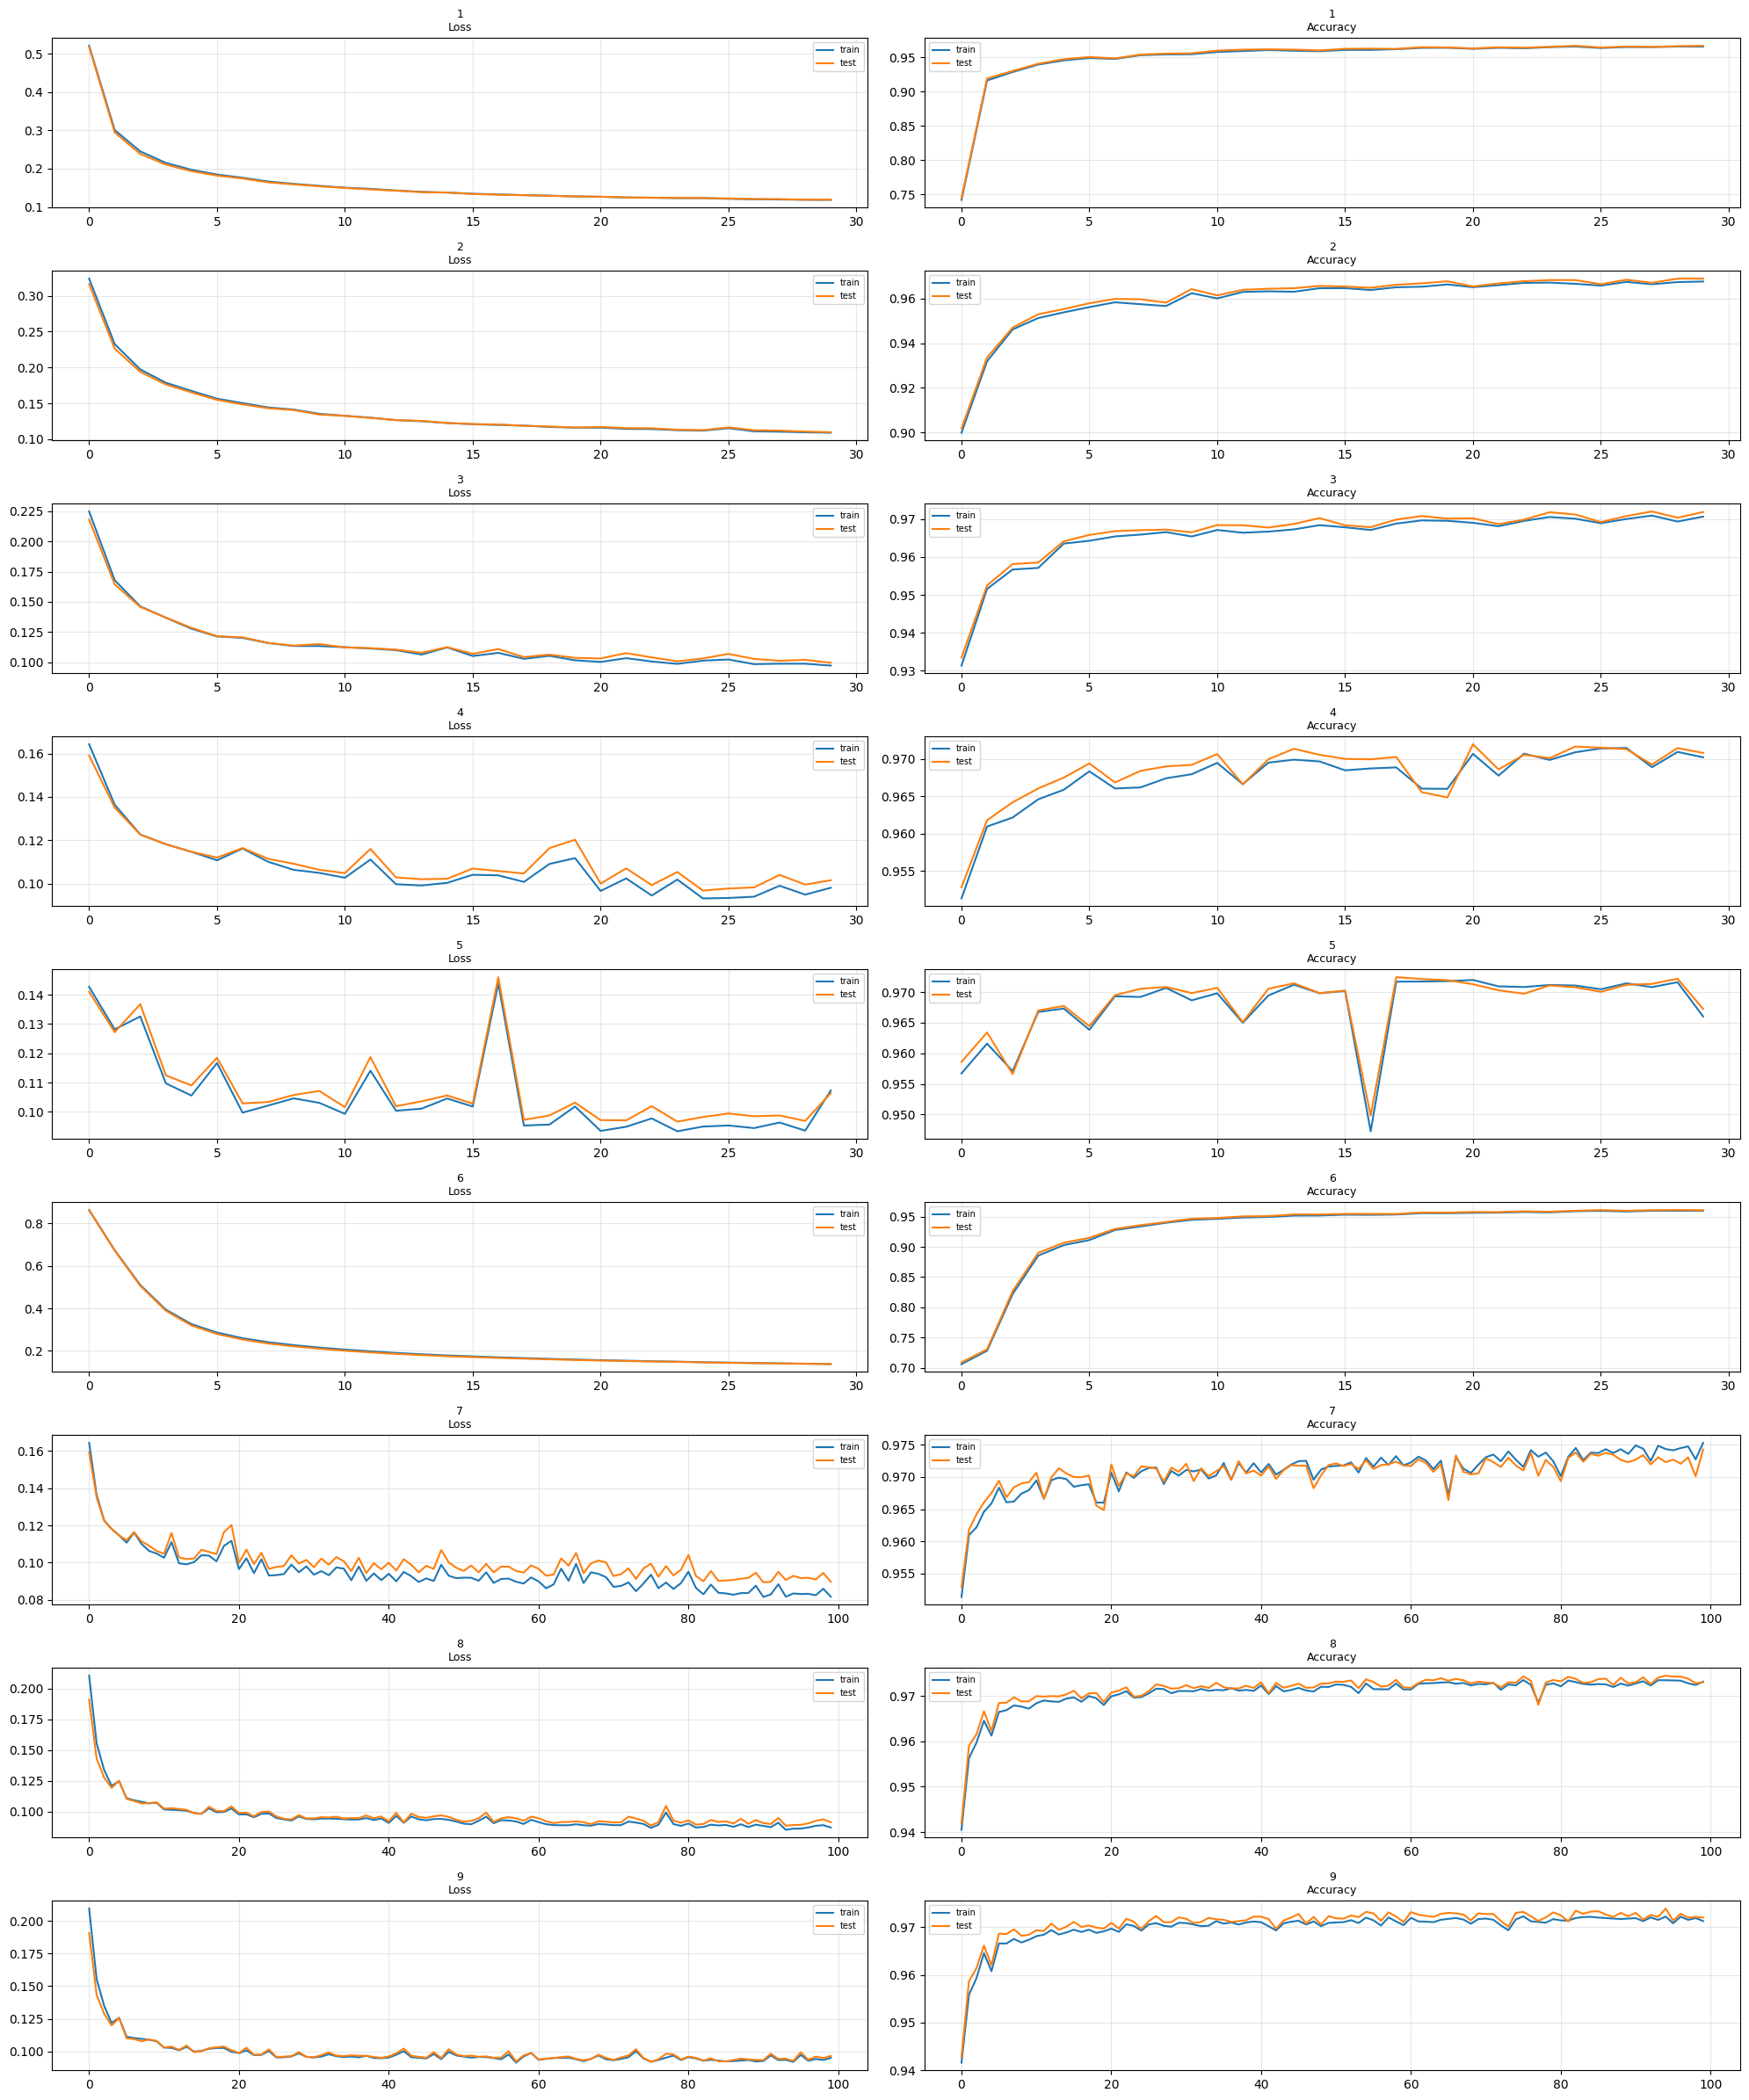

In [8]:
fig, axes = plt.subplots(9, 2, figsize=(20, 24))

for idx, (name, r) in enumerate(results.items()):
    h = r['hist']
    ax_l = axes[idx, 0]
    ax_a = axes[idx, 1]

    ax_l.plot(h['tr_loss'], label='train', lw=1.5)
    ax_l.plot(h['te_loss'], label='test',  lw=1.5)
    ax_l.set_title(f'{name}\nLoss', fontsize=9)
    ax_l.legend(fontsize=7); ax_l.grid(alpha=.3)

    ax_a.plot(h['tr_acc'], label='train', lw=1.5)
    ax_a.plot(h['te_acc'], label='test',  lw=1.5)
    ax_a.set_title(f'{name}\nAccuracy', fontsize=9)
    ax_a.legend(fontsize=7); ax_a.grid(alpha=.3)

plt.tight_layout(); plt.show()

# 7. Relatório das Métricas + Matriz de Confusão

In [9]:
def plot_cm(y_true, y_pred, classes, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, fontsize=8)
    ax.set_yticklabels(classes, fontsize=8)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, f'{cm[i,j]}', ha='center', va='center',
                    fontsize=9, color='white' if cm[i,j] > cm.max()/2 else 'black')
    return im

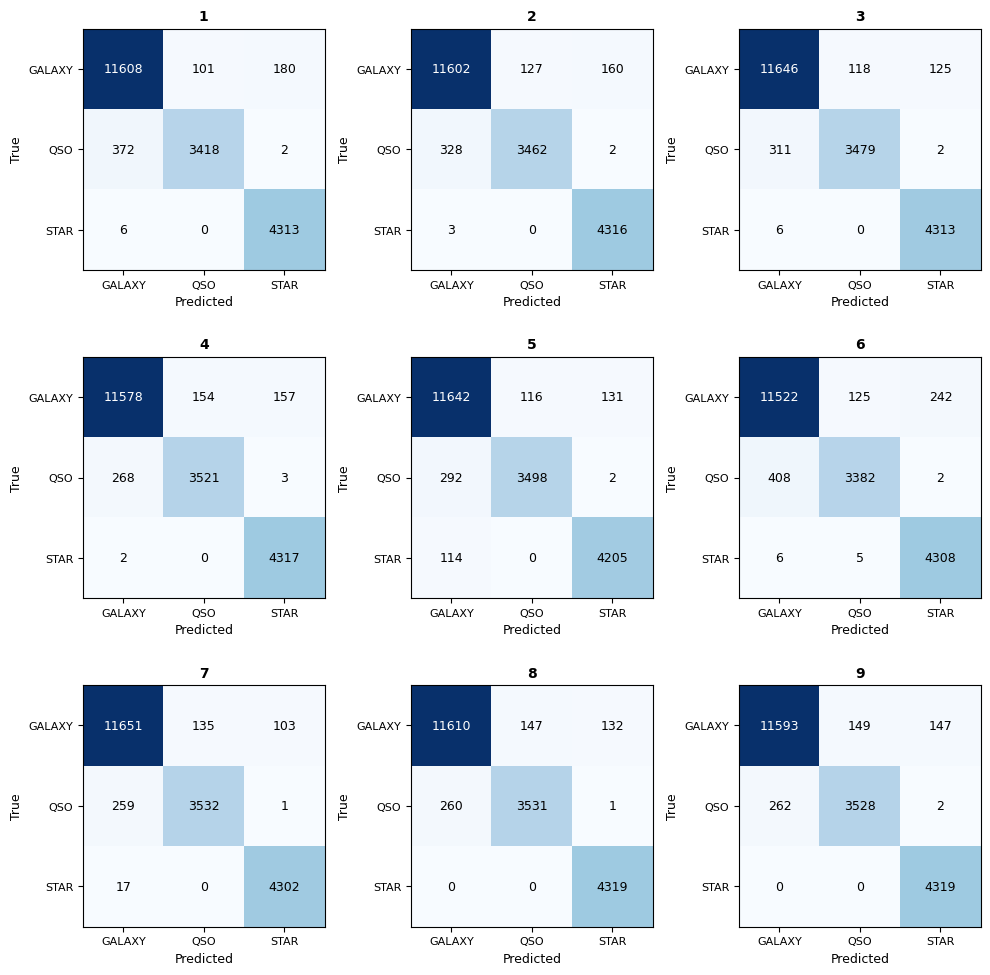

In [10]:
classes = le.classes_
n = len(results)
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for idx, (name, r) in enumerate(results.items()):
    row, col = divmod(idx, 3)
    ax = axes[row, col]
    plot_cm(r['y_true'], r['y_pred'], classes, name, ax)

plt.tight_layout(); plt.show()

In [11]:
for name, r in results.items():
    print(f'\n{"="*60}')
    print(f'  {name}')
    print(f'  hidden={r["cfg"]["hidden"]} lr={r["cfg"]["lr"]} '
          f'epochs={r["cfg"]["epochs"]} dropout={r["cfg"]["p_drop"]} wd={r["cfg"]["wd"]}')
    print(f'{"="*60}')
    print(classification_report(r['y_true'], r['y_pred'], target_names=classes))


  1
  hidden=[32] lr=0.001 epochs=30 dropout=0.0 wd=0.0
              precision    recall  f1-score   support

      GALAXY       0.97      0.98      0.97     11889
         QSO       0.97      0.90      0.94      3792
        STAR       0.96      1.00      0.98      4319

    accuracy                           0.97     20000
   macro avg       0.97      0.96      0.96     20000
weighted avg       0.97      0.97      0.97     20000


  2
  hidden=[128] lr=0.001 epochs=30 dropout=0.0 wd=0.0
              precision    recall  f1-score   support

      GALAXY       0.97      0.98      0.97     11889
         QSO       0.96      0.91      0.94      3792
        STAR       0.96      1.00      0.98      4319

    accuracy                           0.97     20000
   macro avg       0.97      0.96      0.96     20000
weighted avg       0.97      0.97      0.97     20000


  3
  hidden=[64, 32] lr=0.001 epochs=30 dropout=0.0 wd=0.0
              precision    recall  f1-score   support

      G

# 8. Análise dos Experimentos

## Tabela Resumo

| Config | Hidden | LR | Epochs | Dropout | WD | Accuracy | QSO Recall | Diagnóstico |
|--------|--------|----|--------|---------|----|----------|------------|-------------|
| 1 | [32] | 1e-3 | 30 | 0 | 0 | 0.97 | 0.90 | Baseline raso |
| 2 | [128] | 1e-3 | 30 | 0 | 0 | 0.97 | 0.91 | Baseline raso |
| 3 | [64,32] | 1e-3 | 30 | 0 | 0 | 0.97 | 0.92 | Baseline 2-layer |
| 4 | [128,64,32] | 1e-3 | 30 | 0 | 0 | 0.97 | 0.93 | Profundo |
| 5 | [64,32] | 1e-2 | 30 | 0 | 0 | 0.97 | 0.92 | LR alta |
| 6 | [64,32] | 1e-4 | 30 | 0 | 0 | **0.96** | **0.89** |  **Underfitting** |
| 7 | [128,64,32] | 1e-3 | 100 | 0 | 0 | 0.97 | 0.93 | Mais épocas |
| 8 | [128,64,32] | 1e-3 | 100 | 0.3 | 0 | 0.97 | 0.93 | + Dropout |
| 9 | [128,64,32] | 1e-3 | 100 | 0.3 | 1e-4 | 0.97 | 0.93 | + Dropout + L2 |

---

## Diagnóstico: Overfitting e Underfitting

### Underfitting:

A config 6 é o único caso de **underfitting**. A learning rate de `1e-4` é muito baixa para 30 épocas. A Accuracy caiu para 96%, e o recall de QSO foi para 89%, o pior entre todas os experimentos. Tanto treino quanto teste apresentam números baixos, caracterizando o underfitting.

**Solução:** aumentar LR ou aumentar épocas.

### Overfitting: Não observado de forma significativa

Os resultados das configs 7, 8 e 9 revelam que **esse dataset não sofre de overfitting significativo**. O gap entre treino e teste nas configs 7 é uma diferença muito pequena. Isso significa que o dataset é relativamente fácil de separar mesmo para um modelo com 11.587 parâmetros treinado por 100 épocas sem regularização.

Consequência: dropout (config 8) e weight decay (config 9) quase não fazem diferença, a regularização não teve muito efeito.

## Análise por Variável

### Largura (Config 1/2)

Aumentar de [32] para [128] neurônios não teve muita melhora: QSO recall subiu de 0.90 para 0.91. O dataset é simples o suficiente para que uma rede de 32 neurônios tenha resultados decentes.

### Profundidade (Config 1/3/4)

Os testes com diferentes camadas: [32] / [64,32] / [128,64,32] mostrou melhora no recall de QSO (0.90 - 0.92- 0.93). Profundidade ajuda mais que largura para este dataset, por mais que o ganho tenha sido pequeno.

### Learning Rate (Config 3/5/6)

- `lr=1e-2` (config 5): converge melhor a Loss e Acc mas recall de STAR cai levemente (1.00 - 0.97).
- `lr=1e-3` (config 3): Melhor equilíbrio.
- `lr=1e-4` (config 6): **underfitting**. 30 épocas é muito pouco para esse LR.

### Épocas (Config 4/7)

Ambas [128,64,32] com lr=1e-3. Passar de 30 para 100 épocas melhorou QSO recall (0.93 - 0.93) e STAR recall (1.00 - 1.00). Ganho mínimo, reforçando que o modelo já atinge um bom resultado rapidamente.

### Regularização (Config 7/8/9)

| | Dropout | WD | Test Acc | QSO F1 |
|---|---|---|---|---|
| 7 | 0 | 0 | 0.97 | 0.95 |
| 8 | 0.3 | 0 | 0.97 | 0.95 |
| 9 | 0.3 | 1e-4 | 0.97 | 0.94 |

Dropout e weight decay **não melhoraram** basicamente nada. Quando não há overfitting, regularização excessiva pode não fazer diferença ou até prejudicar a avaliação do modelo.

---

## Classe mais difícil: QSO (Quasar)

Em todas as configs, QSO tem o menor recall (89-93%) e menor F1-score. Possíveis razões:

- **Desbalanceamento**: QSO = 3.792 amostras vs GALAXY = 11.889. Modelo tem menos exemplos.
- **Sobreposição de features**: Quasares podem compartilhar características espectrais com galáxias, tornando a distinção de decisão mais difícil.
- STAR é trivial de separar (recall quase 100% em todas os experimentos).

---

## Conclusão

O Stellar Classification Dataset é um problema **relativamente fácil**  para redes neurais. Qualquer arquitetura razoável atinge quase 97% de Acurácia. As principais descobertas:

1. **Underfitting** aparece com lr muito baixa (1e-4) e poucas épocas.
2. **Overfitting** basicamente não apareceu, regularização é desnecessária.
3. **Melhor Config**: [128,64,32], lr = 1e-3, 30-100 epochs, sem regularização (config 4 ou 7).
4. **QSO** é a classe mais difícil de se avaliar possível melhorar com mais amostras ou pesos de classe.